# XGBOOST Model Training


## Load Cleaned Data


In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Import modules
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV

clean_train = pd.read_csv('data/clean_train.csv')
clean_val = pd.read_csv('data/clean_val.csv')

X_tr = clean_train.drop(columns=['target'])
y_tr = clean_train['target']
X_val = clean_val.drop(columns=['target'])
y_val = clean_val['target']


print('X_tr shape:', X_tr.shape)
print('X_val shape:', X_val.shape)
print('y_tr shape:', y_tr.shape)
print('y_val shape:', y_val.shape)


X_tr shape: (24546, 70)
X_val shape: (6011, 70)
y_tr shape: (24546,)
y_val shape: (6011,)


## Target Skewness


Skewness: 2.09


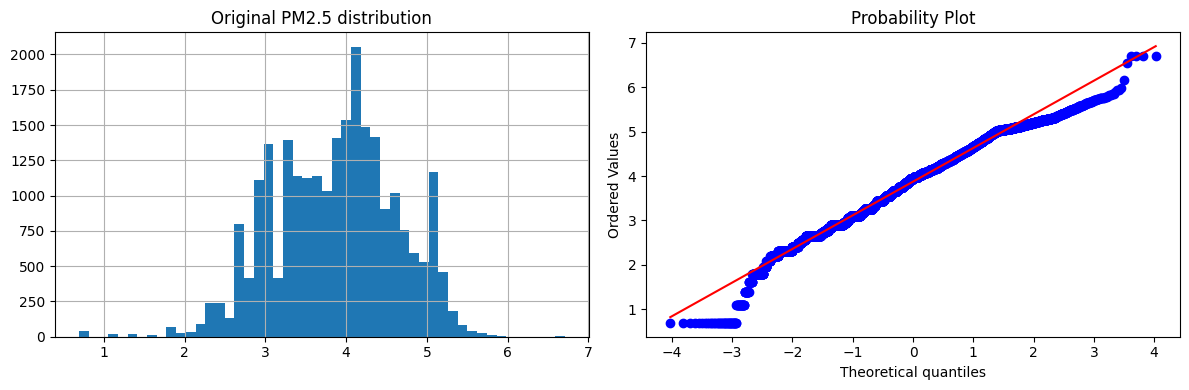

In [34]:
#Handle the target skewness by applying a log transform

import scipy.stats as stats

print(f"Skewness: {y_tr.skew():.2f}")



# Apply log transform
y_tr_log  = np.log1p(y_tr.reset_index(drop=True))
y_val_log = np.log1p(y_val.reset_index(drop=True))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
y_tr_log.hist(bins=50, ax=axes[0])
axes[0].set_title("Original PM2.5 distribution")
stats.probplot(y_tr_log, plot=axes[1])
plt.tight_layout()
plt.show()


Top 25 features by XGBoost:
L3_HCHO_tropospheric_HCHO_column_number_density        0.101287
L3_AER_AI_sensor_altitude                              0.094543
L3_CO_CO_column_number_density                         0.073966
L3_NO2_NO2_column_number_density                       0.048104
L3_NO2_NO2_slant_column_number_density                 0.041079
u_component_of_wind_10m_above_ground                   0.023790
temperature_2m_above_ground                            0.023541
v_component_of_wind_10m_above_ground                   0.022038
L3_HCHO_tropospheric_HCHO_column_number_density_amf    0.020520
L3_CLOUD_cloud_top_pressure                            0.018005
L3_NO2_tropopause_pressure                             0.017711
specific_humidity_2m_above_ground                      0.017491
L3_NO2_sensor_altitude                                 0.016974
day_number                                             0.016283
L3_O3_solar_zenith_angle                               0.015687
L3_SO2_senso

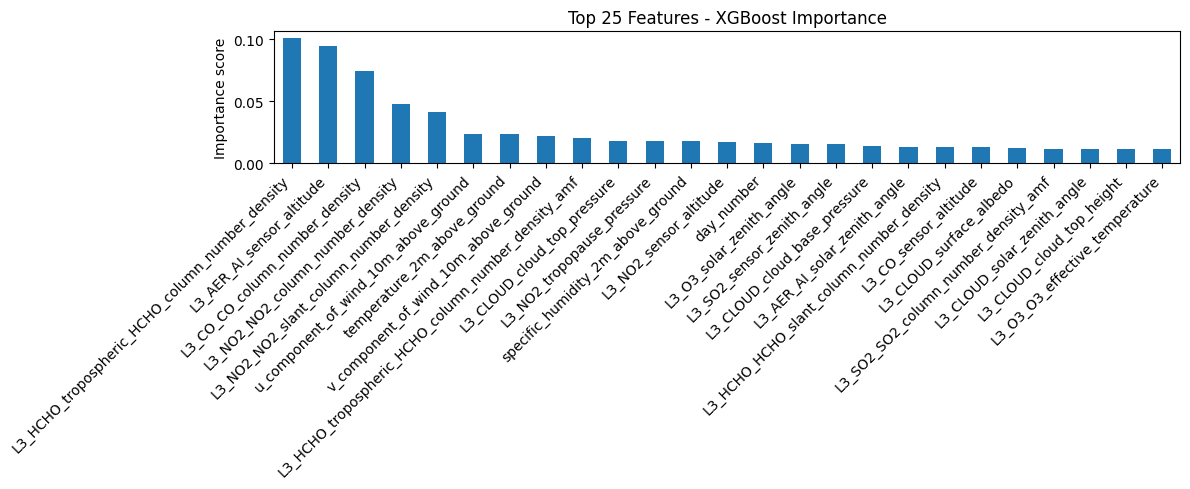

In [ ]:
#Use XGBoostRegressor to fit the train set using all 70 features & predicting top 25

xgb = XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1)
xgb.fit(X_tr, y_tr_log)

xgb_importance = pd.Series(xgb.feature_importances_, index=X_tr.columns)
xgb_importance = xgb_importance.sort_values(ascending=False)

print("Top 25 features by XGBoost:")
print(xgb_importance.head(25))

# Plot
xgb_importance.head(25).plot(kind='bar', figsize=(12, 5))
plt.title("Top 25 Features - XGBoost Importance")
plt.ylabel("Importance score")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [41]:
# Predict and reverse log transform
y_val_pred_xgb = np.expm1(xgb.predict(X_val))

# Compute RMSE
rmse_xgb = np.sqrt(mean_squared_error(y_val, y_val_pred_xgb))
print(f"XGBoost Validation RMSE (all features): {rmse_xgb:.2f} µg/m³")

XGBoost Validation RMSE (all features): 31.87 µg/m³


In [42]:
print(f"Random Forest RMSE: 30.76 µg/m³")
print(f"XGBoost RMSE:       {rmse_xgb:.2f} µg/m³")
print(f"Difference:         {30.76 - rmse_xgb:.2f} µg/m³")


Random Forest RMSE: 30.76 µg/m³
XGBoost RMSE:       31.87 µg/m³
Difference:         -1.11 µg/m³


In [ ]:
#Hyperparameter tuning on XGBoost w/ RandomizedSearchCV for all features

param_grid = {
    'n_estimators':     [300, 500],
    'max_depth':        [9, 12],
    'learning_rate':    [0.01, 0.05, 0.1],
    'subsample':        [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_weight': [1, 3]
}

xgb = XGBRegressor(random_state=42, n_jobs=-1)
search = RandomizedSearchCV(xgb, param_grid, n_iter=30, 
                            cv=5, scoring='neg_root_mean_squared_error',
                            random_state=42, n_jobs=-1)
search.fit(X_tr, y_tr_log)

print("Best params:", search.best_params_)
print("Best CV RMSE:", -search.best_score_)


/Users/karina/neuefische_course/week-9/air_pollution_mlproject/.venv/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best params: {'subsample': 0.6, 'n_estimators': 500, 'min_child_weight': 3, 'max_depth': 9, 'learning_rate': 0.05, 'colsample_bytree': 1.0}
Best CV RMSE: 0.5355035581358935


In [25]:
#Evaluate the best model on validation set:
best_xgb = search.best_estimator_
y_val_pred = np.expm1(best_xgb.predict(X_val))
rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
print(f"Tuned XGBoost RMSE: {rmse:.2f} µg/m³")
print(f"Previous XGBoost RMSE: {rmse_xgb:.2f} µg/m³")


Tuned XGBoost RMSE: 29.32 µg/m³
Previous XGBoost RMSE: 31.87 µg/m³


In [43]:
#Apply XGBRegressor using only top 25 features only
# 
#  Step 1 — select top 25 features
top_25 = xgb_importance.head(25).index.tolist()
X_tr_25  = X_tr[top_25]
X_val_25 = X_val[top_25]

# Step 2 — default XGBoost on top 25 features
xgb_25 = XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1)
xgb_25.fit(X_tr_25, y_tr_log)

y_val_pred_25 = np.expm1(xgb_25.predict(X_val_25))
rmse_xgb_25 = np.sqrt(mean_squared_error(y_val, y_val_pred_25))
print(f"Default XGBoost RMSE (top 25 features): {rmse_xgb_25:.2f} µg/m³")

# Step 3 — tune with RandomizedSearchCV on same top 25 features
param_grid = {
    'n_estimators':     [100, 200, 300, 500],
    'max_depth':        [3, 5, 7, 9],
    'learning_rate':    [0.01, 0.05, 0.1, 0.2],
    'subsample':        [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_weight': [1, 3, 5]
}

search_xgb_25 = RandomizedSearchCV(XGBRegressor(random_state=42, n_jobs=-1),
                                   param_grid, n_iter=30,
                                   cv=5, scoring='neg_root_mean_squared_error',
                                   random_state=42, n_jobs=-1, verbose=1)
search_xgb_25.fit(X_tr_25, y_tr_log)

print("Best params:", search_xgb_25.best_params_)

# Step 4 — evaluate tuned model
best_xgb_25 = search_xgb_25.best_estimator_
y_val_pred_tuned_25 = np.expm1(best_xgb_25.predict(X_val_25))
rmse_xgb_tuned_25 = np.sqrt(mean_squared_error(y_val, y_val_pred_tuned_25))

print(f"Default XGBoost RMSE (top 25): {rmse_xgb_25:.2f} µg/m³")
print(f"Tuned XGBoost RMSE  (top 25): {rmse_xgb_tuned_25:.2f} µg/m³")
print(f"Improvement:                   {rmse_xgb_25 - rmse_xgb_tuned_25:.2f} µg/m³")


Default XGBoost RMSE (top 25 features): 32.52 µg/m³
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params: {'subsample': 1.0, 'n_estimators': 200, 'min_child_weight': 3, 'max_depth': 9, 'learning_rate': 0.1, 'colsample_bytree': 0.6}
Default XGBoost RMSE (top 25): 32.52 µg/m³
Tuned XGBoost RMSE  (top 25): 30.63 µg/m³
Improvement:                   1.89 µg/m³


In [31]:
results = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost (default)', 'XGBoost (tuned, all features)', 'XGBoost (tuned, 25 features)'],
    'RMSE':  [32.03,           31.87,               29.32,                          30.40]
})
results = results.sort_values('RMSE').reset_index(drop=True)
print(results.to_string(index=False))


                        Model  RMSE
XGBoost (tuned, all features) 29.32
 XGBoost (tuned, 25 features) 30.40
            XGBoost (default) 31.87
                Random Forest 32.03


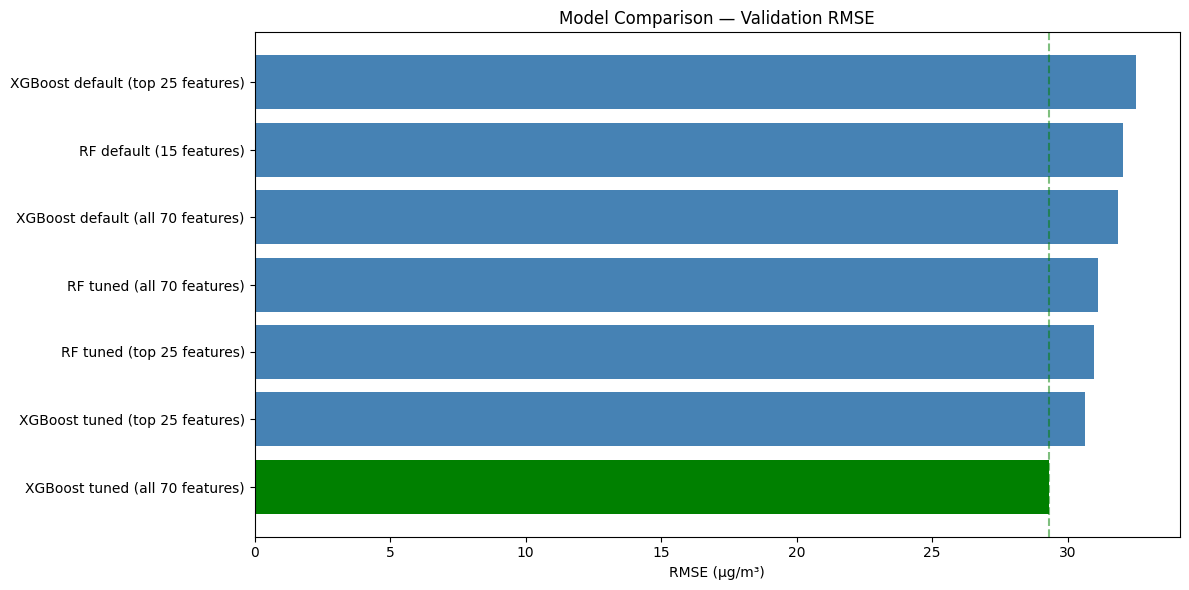

,Model,RMSE
0,XGBoost tuned (all 70 features),29.320000
1,XGBoost tuned (top 25 features),30.627869
2,RF tuned (top 25 features),30.980000
3,RF tuned (all 70 features),31.120000
4,XGBoost default (all 70 features),31.870000
5,RF default (15 features),32.030000
6,XGBoost default (top 25 features),32.518810


In [45]:
results = pd.DataFrame({
    'Model': [
        'RF default (15 features)',
        'RF tuned (all 70 features)',
        'RF tuned (top 25 features)',
        'XGBoost default (all 70 features)',
        'XGBoost default (top 25 features)',
        'XGBoost tuned (all 70 features)',
        'XGBoost tuned (top 25 features)',
    ],
    'RMSE': [
        32.03,          # from random_forest.ipynb
        31.12,     # from random_forest.ipynb — replace with number if not defined
        30.98,     # from random_forest.ipynb — replace with number if not defined
        31.87,          # xgb default all features
        rmse_xgb_25,
        29.32,          # xgb tuned all features
        rmse_xgb_tuned_25,
    ]
})

results = results.sort_values('RMSE').reset_index(drop=True)

# Plot
plt.figure(figsize=(12, 6))
colors = ['green' if r == results['RMSE'].min() else 'steelblue' for r in results['RMSE']]
plt.barh(results['Model'], results['RMSE'], color=colors)
plt.xlabel('RMSE (µg/m³)')
plt.title('Model Comparison — Validation RMSE')
plt.axvline(x=results['RMSE'].min(), color='green', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Print table
results.style.highlight_min(subset=['RMSE'], color='lightgreen')


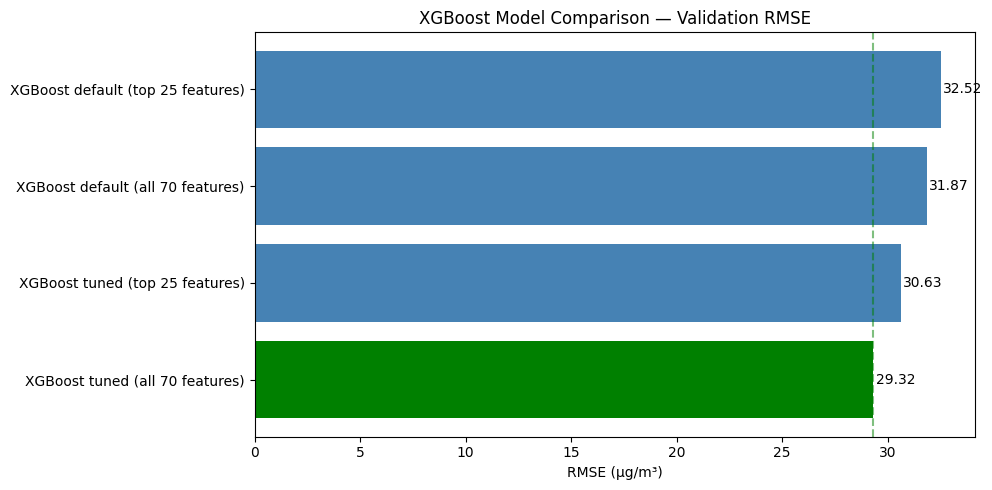

In [46]:
xgb_results = pd.DataFrame({
    'Model': [
        'XGBoost default (all 70 features)',
        'XGBoost default (top 25 features)',
        'XGBoost tuned (all 70 features)',
        'XGBoost tuned (top 25 features)'
    ],
    'RMSE': [
        31.87,
        32.52,
        29.32,
        30.63
    ]
})

xgb_results = xgb_results.sort_values('RMSE').reset_index(drop=True)

plt.figure(figsize=(10, 5))
colors = ['green' if r == xgb_results['RMSE'].min() else 'steelblue' for r in xgb_results['RMSE']]
plt.barh(xgb_results['Model'], xgb_results['RMSE'], color=colors)
plt.xlabel('RMSE (µg/m³)')
plt.title('XGBoost Model Comparison — Validation RMSE')
plt.axvline(x=xgb_results['RMSE'].min(), color='green', linestyle='--', alpha=0.5)
for i, v in enumerate(xgb_results['RMSE']):
    plt.text(v + 0.1, i, f'{v:.2f}', va='center')
plt.tight_layout()
plt.show()


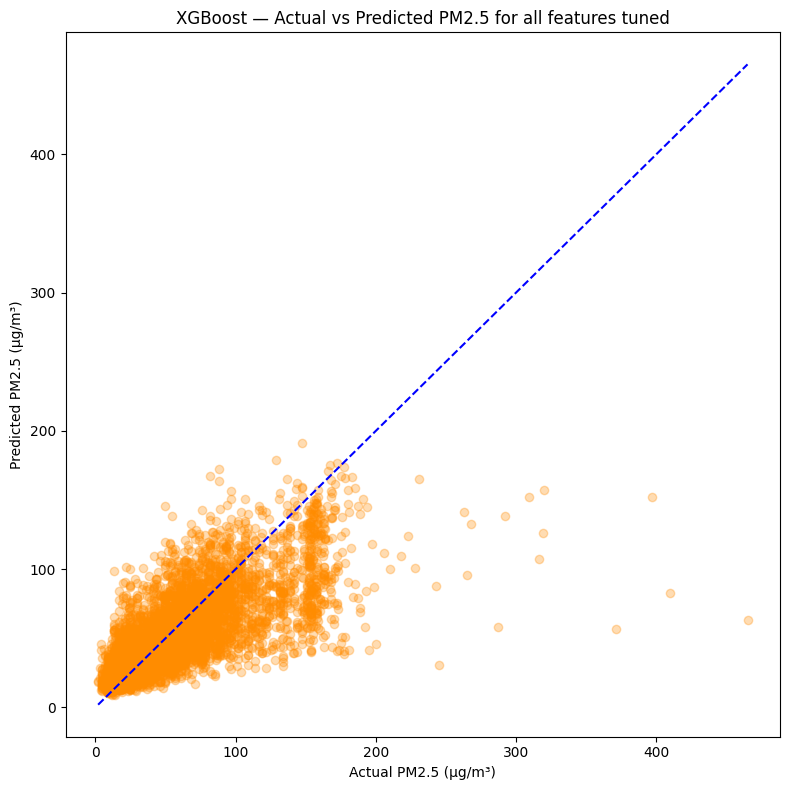

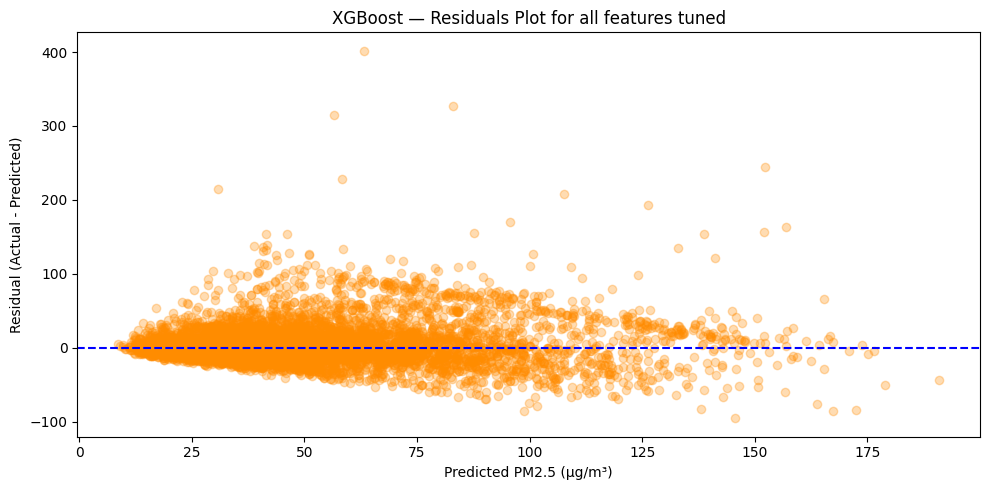

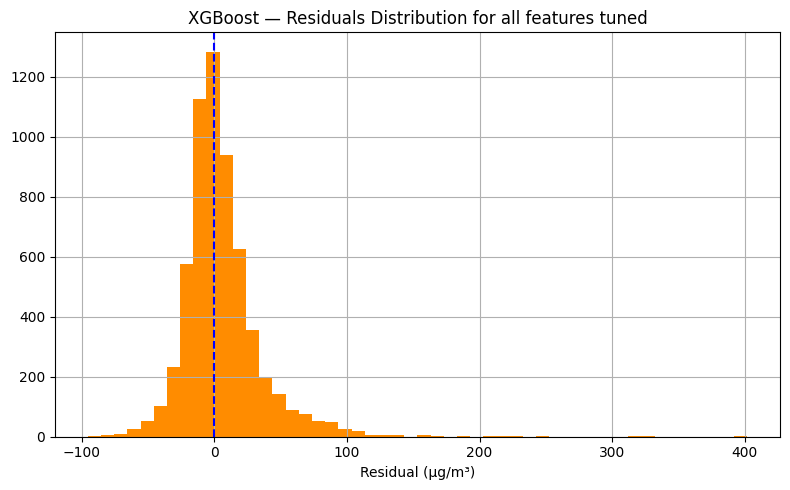

In [53]:
# Actual vs Predicted for XGB for all features tuned
plt.figure(figsize=(8, 8))
plt.scatter(y_val, y_val_pred, alpha=0.3, color='darkorange')
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'b--')
plt.xlabel("Actual PM2.5 (µg/m³)")
plt.ylabel("Predicted PM2.5 (µg/m³)")
plt.title("XGBoost — Actual vs Predicted PM2.5 for all features tuned")
plt.tight_layout()
plt.show()

# Residuals plot for XGB for all features tuned
residuals = y_val - y_val_pred

plt.figure(figsize=(10, 5))
plt.scatter(y_val_pred, residuals, alpha=0.3, color='darkorange')
plt.axhline(0, color='blue', linestyle='--')
plt.xlabel("Predicted PM2.5 (µg/m³)")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("XGBoost — Residuals Plot for all features tuned")
plt.tight_layout()
plt.show()

# Residuals distribution
plt.figure(figsize=(8, 5))
residuals.hist(bins=50, color='darkorange')
plt.axvline(0, color='blue', linestyle='--')
plt.xlabel("Residual (µg/m³)")
plt.title("XGBoost — Residuals Distribution for all features tuned")
plt.tight_layout()
plt.show()


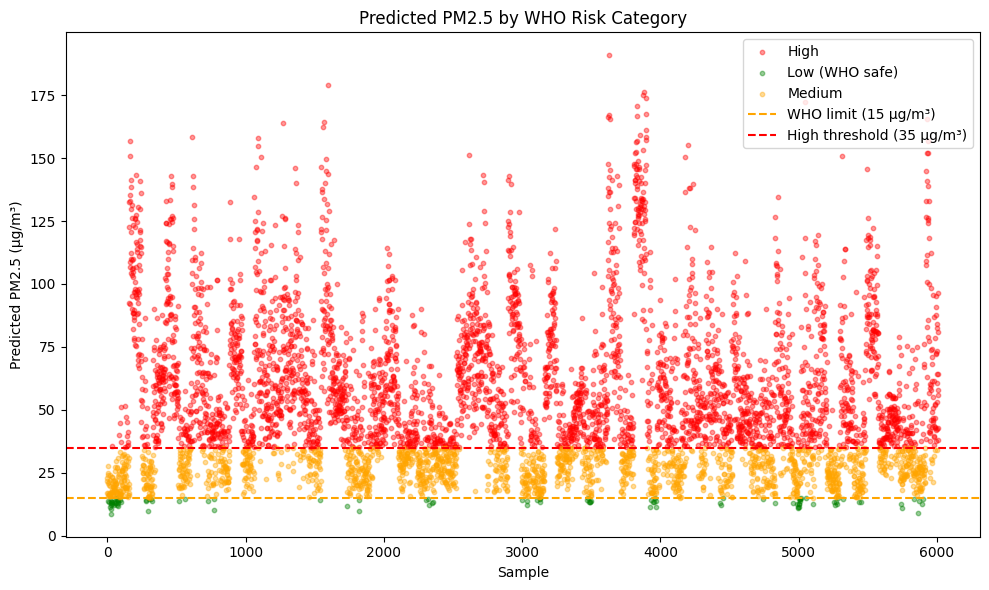

Category
High              4017
Medium            1896
Low (WHO safe)      98
Name: count, dtype: int64

Total predictions: 6011
% Low  (≤15):  1.6%
% Medium (15-35): 31.5%
% High  (>35):  66.8%


In [54]:
# Define WHO-based thresholds for daily PM2.5
def get_category(val):
    if val <= 15:
        return 'Low (WHO safe)'
    elif val <= 35:
        return 'Medium'
    else:
        return 'High'

# Create a DataFrame with predictions and categories
pred_df = pd.DataFrame({
    'Actual':    y_val.values,
    'Predicted': y_val_pred
})
pred_df['Category'] = pred_df['Predicted'].apply(get_category)

# Plot predicted values colored by category
colors = {'Low (WHO safe)': 'green', 'Medium': 'orange', 'High': 'red'}

plt.figure(figsize=(10, 6))
for category, group in pred_df.groupby('Category'):
    plt.scatter(group.index, group['Predicted'], 
                label=category, color=colors[category], alpha=0.4, s=10)

# Add threshold lines
plt.axhline(y=15, color='orange', linestyle='--', linewidth=1.5, label='WHO limit (15 µg/m³)')
plt.axhline(y=35, color='red',    linestyle='--', linewidth=1.5, label='High threshold (35 µg/m³)')

plt.xlabel("Sample")
plt.ylabel("Predicted PM2.5 (µg/m³)")
plt.title("Predicted PM2.5 by WHO Risk Category")
plt.legend()
plt.tight_layout()
plt.show()

# Print summary
print(pred_df['Category'].value_counts())
print(f"\nTotal predictions: {len(pred_df)}")
print(f"% Low  (≤15):  {(pred_df['Category'] == 'Low (WHO safe)').mean()*100:.1f}%")
print(f"% Medium (15-35): {(pred_df['Category'] == 'Medium').mean()*100:.1f}%")
print(f"% High  (>35):  {(pred_df['Category'] == 'High').mean()*100:.1f}%")


In [55]:
print(y_tr.describe())


count    24546.000000
mean        62.030995
std         47.960782
min          1.000000
25%         26.000000
50%         51.000000
75%         80.000000
max        815.000000
Name: target, dtype: float64


Low threshold  (33rd percentile): 34.0 µg/m³
High threshold (66th percentile): 65.0 µg/m³
Mean PM2.5: 62.0 µg/m³


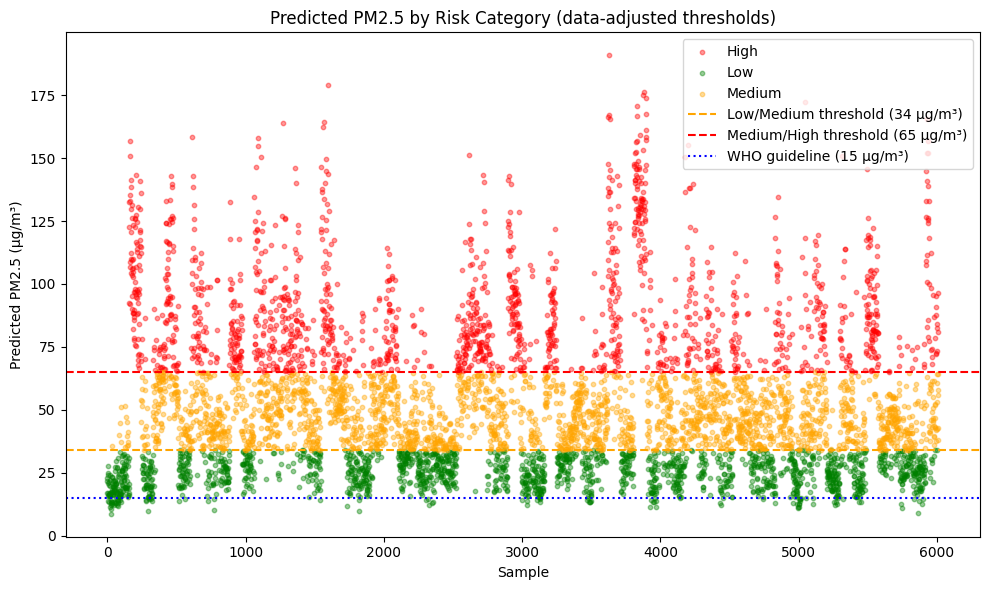


% Low    (≤34 µg/m³):  31.2%
% Medium (34–65 µg/m³): 41.5%
% High   (>65 µg/m³):  27.3%


In [56]:
# Define thresholds based on your y_tr training data distribution
low_threshold    = y_tr.quantile(0.33)   # bottom third
high_threshold   = y_tr.quantile(0.66)   # top third

print(f"Low threshold  (33rd percentile): {low_threshold:.1f} µg/m³")
print(f"High threshold (66th percentile): {high_threshold:.1f} µg/m³")
print(f"Mean PM2.5: {y_tr.mean():.1f} µg/m³")

# Categorise predictions
def get_category(val):
    if val <= low_threshold:
        return 'Low'
    elif val <= high_threshold:
        return 'Medium'
    else:
        return 'High'

pred_df = pd.DataFrame({
    'Actual':    y_val.values,
    'Predicted': y_val_pred
})
pred_df['Category'] = pred_df['Predicted'].apply(get_category)

# Plot
colors = {'Low': 'green', 'Medium': 'orange', 'High': 'red'}

plt.figure(figsize=(10, 6))
for category, group in pred_df.groupby('Category'):
    plt.scatter(group.index, group['Predicted'],
                label=category, color=colors[category], alpha=0.4, s=10)

plt.axhline(y=low_threshold,  color='orange', linestyle='--', linewidth=1.5, 
            label=f'Low/Medium threshold ({low_threshold:.0f} µg/m³)')
plt.axhline(y=high_threshold, color='red',    linestyle='--', linewidth=1.5, 
            label=f'Medium/High threshold ({high_threshold:.0f} µg/m³)')
plt.axhline(y=15, color='blue', linestyle=':', linewidth=1.5,
            label='WHO guideline (15 µg/m³)')

plt.xlabel("Sample")
plt.ylabel("Predicted PM2.5 (µg/m³)")
plt.title("Predicted PM2.5 by Risk Category (data-adjusted thresholds)")
plt.legend()
plt.tight_layout()
plt.show()

# Summary
print(f"\n% Low    (≤{low_threshold:.0f} µg/m³):  {(pred_df['Category'] == 'Low').mean()*100:.1f}%")
print(f"% Medium ({low_threshold:.0f}–{high_threshold:.0f} µg/m³): {(pred_df['Category'] == 'Medium').mean()*100:.1f}%")
print(f"% High   (>{high_threshold:.0f} µg/m³):  {(pred_df['Category'] == 'High').mean()*100:.1f}%")
